# Анализ результатов: Моделирование сезонности в временных рядах

Как лучше всего моделирование сезонности?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
results_files = list(Path('.').glob('experiment_results_*_main.csv'))
if not results_files:
    raise FileNotFoundError("Файлы с результатами не найдены!")

latest_file = max(results_files, key=lambda x: x.stat().st_mtime)

df = pd.read_csv(latest_file)

df_baseline = df[df['type'] == 'baseline_cv'].copy()
df_catboost = df[df['type'] == 'ml_cv'].copy()

df_baseline['model_name'] = df_baseline['model'].str.replace('Simple_', '')
df_catboost['model_name'] = df_catboost['model'].str.replace('CatBoost_', '')

summary = df.groupby(['model', 'horizon']).agg({
    'avg_sMAPE': 'first',
    'std_sMAPE': 'first',
    'avg_MAE': 'first',
    'avg_RMSE': 'first'
}).reset_index()

display(summary)

,model,horizon,avg_sMAPE,std_sMAPE,avg_MAE,avg_RMSE
0,CatBoost_all_features,6,5.017022,NaN,203.801469,329.382727
1,CatBoost_all_features,12,4.969381,NaN,223.072256,396.686054
2,CatBoost_all_features,18,5.310149,NaN,237.472904,458.463842
3,CatBoost_lags_calendar,6,5.926702,0.935729,217.677064,396.994998
4,CatBoost_lags_calendar,12,6.011482,0.976426,217.575783,388.388084
5,CatBoost_lags_calendar,18,6.011175,0.818367,216.525052,388.361415
6,CatBoost_lags_fourier,6,6.145434,1.346415,222.847535,432.884822
7,CatBoost_lags_fourier,12,6.164286,1.400959,221.388990,411.976251
8,CatBoost_lags_fourier,18,6.162471,1.231920,219.466223,405.257610
9,CatBoost_lags_only,6,6.335374,1.114049,222.393014,387.436042


## CatBoost vs Baseline:

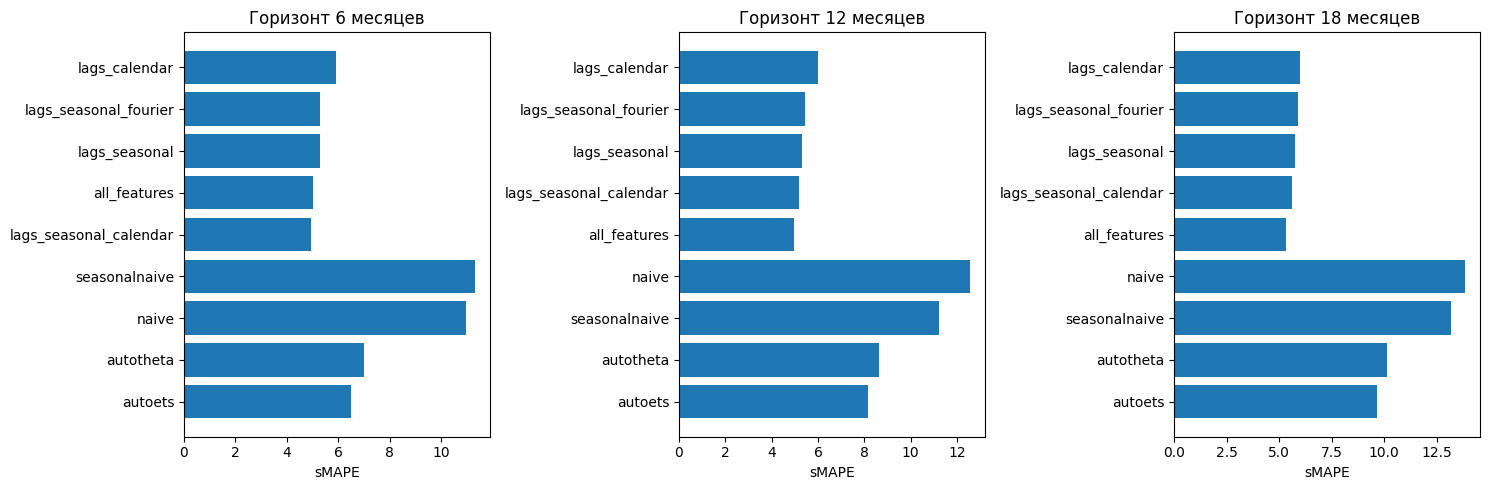

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

horizons = sorted(df['horizon'].unique())

for idx, horizon in enumerate(horizons):
    ax = axes[idx]
    
    baseline_h = df_baseline[df_baseline['horizon'] == horizon].sort_values('avg_sMAPE')
    catboost_h = df_catboost[df_catboost['horizon'] == horizon].sort_values('avg_sMAPE').head(5)
    
    combined = pd.concat([
        baseline_h[['model_name', 'avg_sMAPE']],
        catboost_h[['model_name', 'avg_sMAPE']]
    ])
    
    ax.barh(range(len(combined)), combined['avg_sMAPE'])
    ax.set_yticks(range(len(combined)))
    ax.set_yticklabels(combined['model_name'])
    ax.set_xlabel('sMAPE')
    ax.set_title(f'Горизонт {horizon} месяцев')
    
plt.tight_layout()
plt.show()

## Сравнение наборов признаков CatBoost:

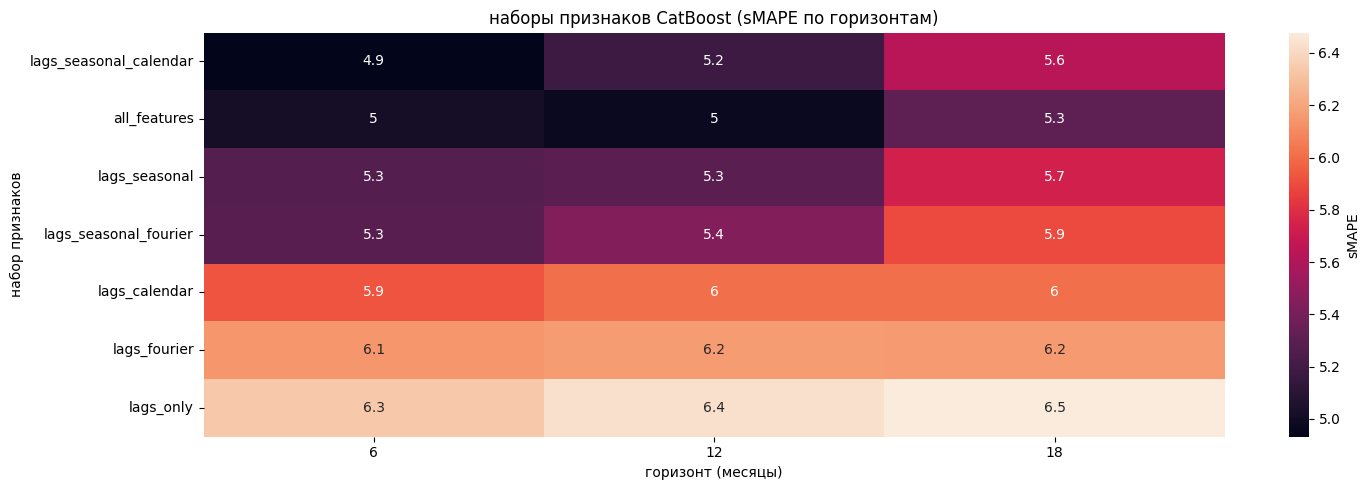

In [5]:
pivot = df_catboost.pivot(index='model_name', columns='horizon', values='avg_sMAPE').sort_values(by=6)

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot, annot=True, cbar_kws={'label': 'sMAPE'}, ax=ax)

ax.set_title('наборы признаков CatBoost (sMAPE по горизонтам)')
ax.set_xlabel('горизонт (месяцы)')
ax.set_ylabel('набор признаков')

plt.tight_layout()
plt.show()

feature_stats = df_catboost.groupby('model_name').agg({
    'avg_sMAPE': 'mean',
    'n_features': 'first'
}).sort_values('avg_sMAPE')

## Зависимость от горизонта прогнозирования

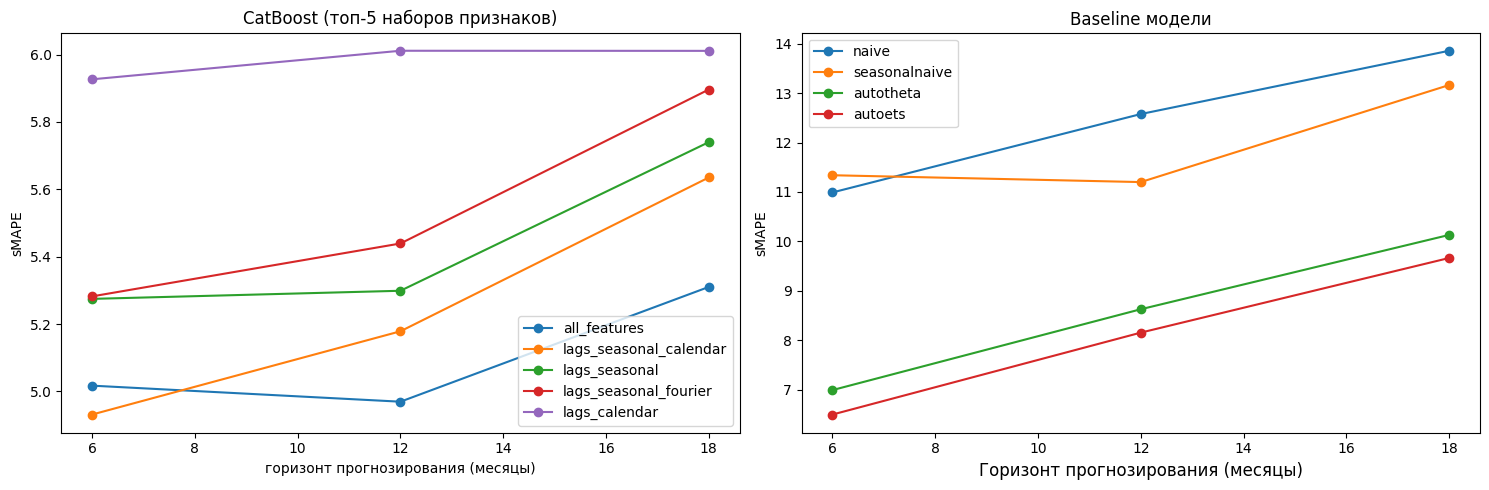


Деградация качества:
CatBoost:
  6 -> 12: +0.8%,
  12 -> 18: +6.9%
AutoETS:
  6 -> 12: +25.5%,
  12 -> 18: +18.5%


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

top_catboost = df_catboost.groupby('model_name')['avg_sMAPE'].mean().nsmallest(5).index
for model in top_catboost:
    model_data = df_catboost[df_catboost['model_name'] == model]
    ax1.plot(model_data['horizon'], model_data['avg_sMAPE'], marker='o',label=model)

ax1.set_xlabel('горизонт прогнозирования (месяцы)')
ax1.set_ylabel('sMAPE')
ax1.set_title('CatBoost (топ-5 наборов признаков)')
ax1.legend()

for model in df_baseline['model_name'].unique():
    model_data = df_baseline[df_baseline['model_name'] == model]
    ax2.plot(model_data['horizon'], model_data['avg_sMAPE'], marker='o', label=model)

ax2.set_xlabel('Горизонт прогнозирования (месяцы)', fontsize=12)
ax2.set_ylabel('sMAPE')
ax2.set_title('Baseline модели')
ax2.legend()

plt.tight_layout()
plt.show()

print('\nДеградация качества:')
for model_type, df_subset in [
    ('CatBoost', df_catboost.groupby('horizon')['avg_sMAPE'].min()),
    ('AutoETS', df_baseline[df_baseline['model_name']=='autoets'].set_index('horizon')['avg_sMAPE'])
]:
    print(f'{model_type}:')
    print(f'  6 -> 12: {(df_subset[12] / df_subset[6] - 1) * 100:+.1f}%,')
    print(f'  12 -> 18: {(df_subset[18] / df_subset[12] - 1) * 100:+.1f}%')